# 梯度下降法(Gradient Descent)

## 範例1. 假定目標函數 f(x) = $x^2$，而非MSE，請使用梯度下降法求取最小值

In [1]:
# 載入套件
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 目標函數(損失函數):y=x^2
def func(x: float | np.ndarray) -> float | np.ndarray:
    return x**2  # np.square(x)


# 目標函數的一階導數:dy/dx=2*x
def dfunc(x: float | np.ndarray) -> float | np.ndarray:
    return 2 * x

In [3]:
# 梯度下降
# x_start: x的起始點
# df: 目標函數的一階導數
# epochs: 執行週期
# lr: 學習率
def GD(
    x_start: float,
    df: Callable[[float | np.ndarray], float | np.ndarray],
    epochs: int,
    lr: float,
) -> np.ndarray:
    xs = np.zeros(epochs + 1)
    x = x_start
    xs[0] = x
    for i in range(epochs):
        dx = df(x)
        # x更新 x_new = x — learning_rate * gradient
        x -= dx * lr
        xs[i + 1] = x
    return xs

## 梯度下降法(Gradient Descent)示意圖

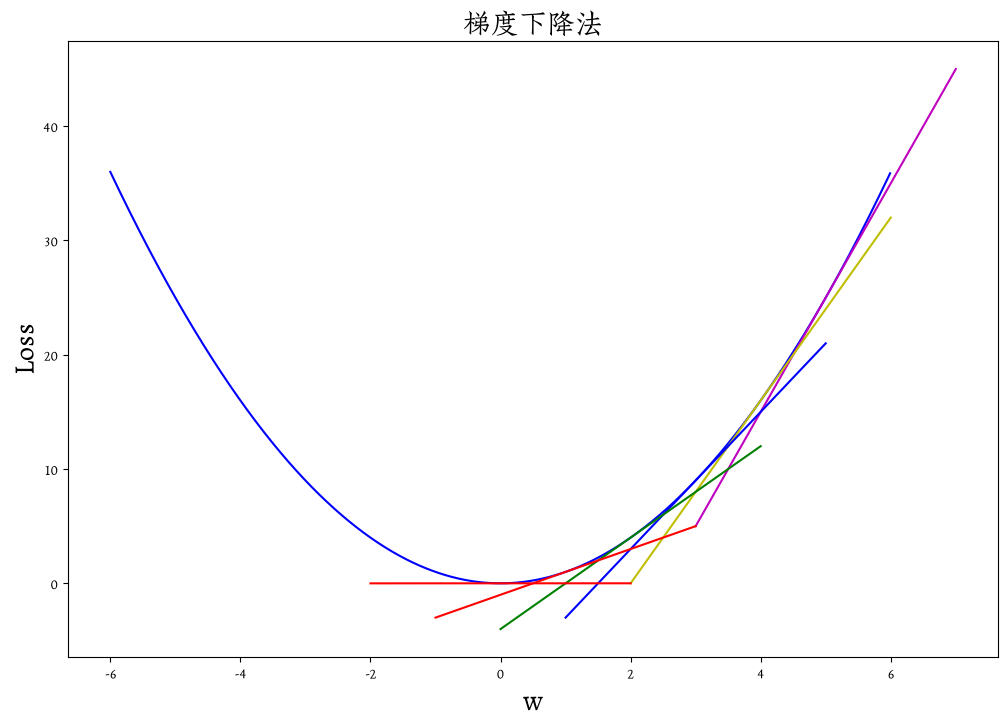

In [4]:
# 超參數(Hyperparameters)
x_start = 5  # 起始權重
epochs = 15  # 執行週期數
lr = 0.3  # 學習率

# 梯度下降法
w = GD(x_start, dfunc, epochs, lr=lr)

# 函數 y=x^2 繪圖
plt.figure(figsize=(12, 8))
t = np.arange(-6.0, 6.0, 0.01)
plt.plot(t, func(t), c='b')

plt.rcParams['font.sans-serif'] = ['Zhuque Fangsong (technical preview)']  # 正黑體
plt.rcParams['axes.unicode_minus'] = False  # 矯正負號

plt.title('梯度下降法', fontsize=20)
plt.xlabel('w', fontsize=20)
plt.ylabel('Loss', fontsize=20)

color = list('rgbymr')  # 切線顏色
line_offset = 2  # 切線長度
for i in range(5, -1, -1):
    # 取相近兩個點，畫切線(tangent line)
    z = np.array([i + 0.001, i])
    vec = np.vectorize(func)
    cls = np.polyfit(z, vec(z), deg=1)
    p = np.poly1d(cls)

    # 畫切線
    x = np.array([i + line_offset, i - line_offset])
    y = np.array([(i + line_offset) * p[1] + p[0], (i - line_offset) * p[1] + p[0]])
    plt.plot(x, y, c=color[i - 1])
plt.show()

## 執行梯度下降法(Gradient Descent)

[5.   2.   0.8  0.32 0.13 0.05 0.02 0.01 0.   0.   0.   0.   0.   0.
 0.   0.  ]


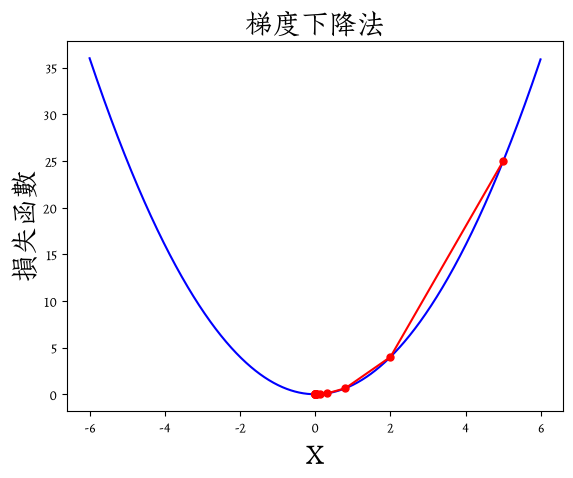

In [5]:
# 超參數(Hyperparameters)
x_start = 5  # 起始權重
epochs = 15  # 執行週期數
lr = 0.3  # 學習率

# 梯度下降法
# *** Function 可以直接當參數傳遞 ***
w = GD(x_start, dfunc, epochs, lr=lr)
print(np.around(w, 2))

t = np.arange(-6.0, 6.0, 0.01)
plt.plot(t, func(t), c='b')
plt.plot(w, func(w), c='r', marker='o', markersize=5)

# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Zhuque Fangsong (technical preview)']  # 正黑體
plt.rcParams['axes.unicode_minus'] = False  # 矯正負號

plt.title('梯度下降法', fontsize=20)
plt.xlabel('X', fontsize=20)
plt.ylabel('損失函數', fontsize=20)
plt.show()

## 範例2. 假定損失函數如下，請使用梯度下降法求取最小值
$2x^4-3x-20$

In [6]:
# 損失函數
def func(x: float | np.ndarray) -> float | np.ndarray:
    return 2 * x**4 - 3 * x**2 + 2 * x - 20


# 損失函數一階導數
def dfunc(x: float | np.ndarray) -> float | np.ndarray:
    return 8 * x**3 - 6 * x + 2

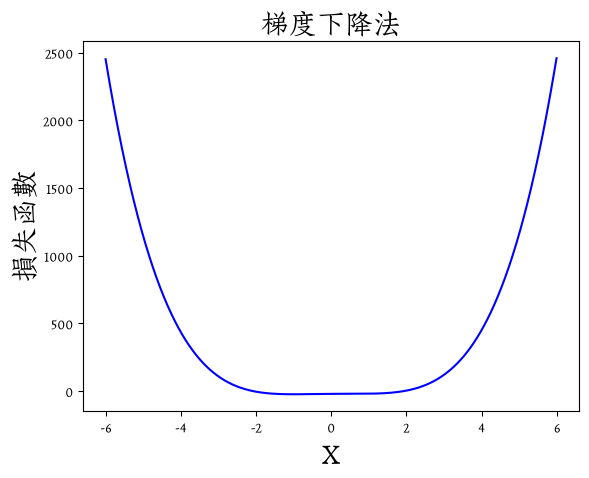

In [7]:
t = np.arange(-6.0, 6.0, 0.01)
plt.plot(t, func(t), c='b')

# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Zhuque Fangsong (technical preview)']  # 正黑體
plt.rcParams['axes.unicode_minus'] = False  # 矯正負號

plt.title('梯度下降法', fontsize=20)
plt.xlabel('X', fontsize=20)
plt.ylabel('損失函數', fontsize=20)
plt.show()

## 執行梯度下降法(Gradient Descent)

[5.   4.03 3.53 ... 0.51 0.51 0.51]


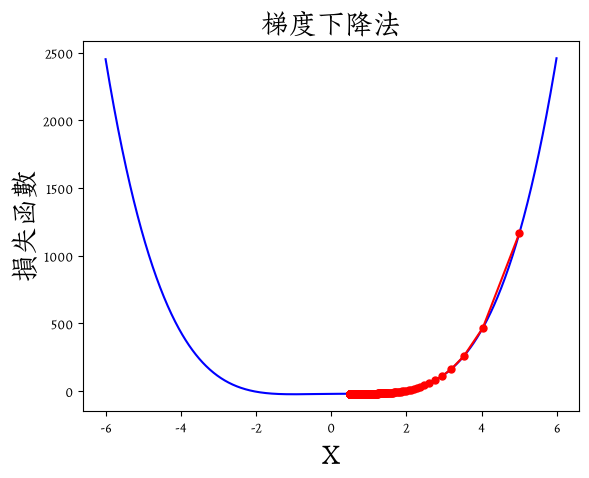

In [8]:
# 超參數(Hyperparameters)
x_start = 5  # 起始權重
epochs = 15000  # 執行週期數
lr = 0.001  # 學習率

# 梯度下降法
# *** Function 可以直接當參數傳遞 ***
w = GD(x_start, dfunc, epochs, lr=lr)
print(np.around(w, 2))

color = 'r'

t = np.arange(-6.0, 6.0, 0.01)
plt.plot(t, func(t), c='b')
plt.plot(w, func(w), c='r', marker='o', markersize=5)

# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Zhuque Fangsong (technical preview)']  # 正黑體
plt.rcParams['axes.unicode_minus'] = False  # 矯正負號

plt.title('梯度下降法', fontsize=20)
plt.xlabel('X', fontsize=20)
plt.ylabel('損失函數', fontsize=20)
plt.show()

# 📉 均方誤差（MSE）損失函數的梯度計算與推導

在訓練模型時，我們不會直接去解複雜的反矩陣，而是透過 **梯度下降法（Gradient Descent）** 一步步更新參數。這時我們需要求出損失函數對權重 $w$ 與偏差 $b$ 的**梯度（Gradient）**。

---

## 1. 基礎：單一特徵（標量形式）的梯度

### 📌 MSE 損失函數定義
假設有 $n$ 筆樣本，模型預測值為 $\hat{y}_i = wx_i + b$，真實值為 $y_i$。均方誤差（MSE）定義為：
$$L(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - (wx_i + b))^2$$

### 🛠 對權重 $w$ 求偏導（連鎖律）
根據微積分連鎖律，將外層平方微分（移到前面變成 2），再對內層的 $w$ 求微分（內層對 $w$ 微分得到 $-x_i$）：
$$\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - (wx_i + b)) \cdot (-x_i)$$

整理後，得到 **$w$ 的梯度公式**：
$$\boxed{\frac{\partial L}{\partial w} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)x_i}$$

### 🛠 對偏差 $b$ 求偏導
同理，內層對 $b$ 求微分（內層對 $b$ 微分得到 $-1$）：
$$\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} 2(y_i - (wx_i + b)) \cdot (-1)$$

整理後，得到 **$b$ 的梯度公式**：
$$\boxed{\frac{\partial L}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)}$$

---

## 2. 進階：多維特徵（矩陣與向量形式）的梯度

在實務上（如 TensorFlow, PyTorch 或 NumPy 實作），我們通常將所有特徵與偏差併入矩陣運算。

### 📌 矩陣形式的 MSE 定義
設特徵矩陣為 $\mathbf{X}$（大小 $n \times d$），真實標籤為向量 $\mathbf{y}$（大小 $n \times 1$），權重向量為 $\mathbf{w}$（大小 $d \times 1$）。預測向量為 $\mathbf{\hat{y}} = \mathbf{X}\mathbf{w}$。
> *註：此處已將偏差 $b$ 併入 $\mathbf{w}$ 的第一個元素，並在 $\mathbf{X}$ 第一列補 1。*

$$L(\mathbf{w}) = \frac{1}{n} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 = \frac{1}{n} (\mathbf{y} - \mathbf{X}\mathbf{w})^T(\mathbf{y} - \mathbf{X}\mathbf{w})$$

展開矩陣（如前一章推導）：
$$L(\mathbf{w}) = \frac{1}{n} \left( \mathbf{y}^T\mathbf{y} - 2\mathbf{w}^T\mathbf{X}^T\mathbf{y} + \mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w} \right)$$

### 🛠 矩陣梯度的推導
我們對向量 $\mathbf{w}$ 求導（Gradient $\nabla_{\mathbf{w}} L$），應用矩陣微分公式：
1. $\frac{\partial (\mathbf{w}^T\mathbf{a})}{\partial \mathbf{w}} = \mathbf{a}$
2. $\frac{\partial (\mathbf{w}^T\mathbf{A}\mathbf{w})}{\partial \mathbf{w}} = 2\mathbf{A}\mathbf{w}$

$$\nabla_{\mathbf{w}} L = \frac{\partial L}{\partial \mathbf{w}} = \frac{1}{n} \left( 0 - 2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\mathbf{w} \right)$$
$$\nabla_{\mathbf{w}} L = \frac{2}{n} \left( \mathbf{X}^T\mathbf{X}\mathbf{w} - \mathbf{X}^T\mathbf{y} \right)$$

提出共同項 $\mathbf{X}^T$，得到最終**矩陣形式的梯度公式**：
$$\boxed{\nabla_{\mathbf{w}} L = \frac{2}{n} \mathbf{X}^T (\mathbf{X}\mathbf{w} - \mathbf{y}) = \frac{2}{n} \mathbf{X}^T (\mathbf{\hat{y}} - \mathbf{y})}$$

> 💡 **幾何與直觀意義：** 
> 梯度的核心是 **`(預測值 - 真實值)` 乘以 `特徵值 X`**。
> 如果預測值太高（$\mathbf{\hat{y}} - \mathbf{y} > 0$），梯度為正，參數更新時減去梯度，預測值就會下降；反之亦然。這就是模型自我修正的原理！
